# 【Supertone/supertonic-3】31语言端侧TTS语音合成模型

---

## 一、项目简介

### 1.1 官方项目简介

Supertonic-3 是韩国 Supertone Inc. 开源的第三个代端侧文本转语音（TTS）系统。仅 **99M 参数**，基于 **ONNX Runtime** ，支持 **31 种语言**，在树莓派上即可实时合成语音。

核心特性：
- 31 种语言合成（英/韩/日/法/德/西/葡/俄/阿等）
- 支持情感标签：`<laugh>` `<breath>` `<sigh>`
- 模型仅 305MB，首次运行自动下载
- 自然文本归一化（金额/时间/电话号码自动处理）
- OpenRAIL-M 许可证

### 1.2 本项目简介

本项目在趋动云平台复现了 Supertone-3，提供一键启动的 Gradio WebUI 界面，无需配置环境即可使用。

---

## 二、官方链接

- 官方 GitHub：https://github.com/supertone-inc/supertonic
- 官方 Hugging Face：https://huggingface.co/Supertone/supertonic-3
- 官方论文：https://arxiv.org/abs/2503.23108

---

## 三、算力推荐

- 最低配置：B1.small（4核 8GB 内存）
- 推荐配置：B1.medium（8核 16GB 内存）


---

## 四、使用说明

### 4.1 一键启动命令


In [2]:
! python app.py --server_name 0.0.0.0 --server_port 7860

Fetching 26 files:   0%|                                 | 0/26 [00:00<?, ?it/s]
LICENSE: 15.0kB [00:00, 1.82MB/s]

.gitattributes: 85.0B [00:00, 295kB/s]
Fetching 26 files:   4%|▉                        | 1/26 [00:00<00:24,  1.04it/s]
README.md: 5.39kB [00:00, 16.3MB/s]

config.json: 174B [00:00, 637kB/s]A

.gitignore: 100%|████████████████████████████| 22.0/22.0 [00:00<00:00, 98.4kB/s]
Fetching 26 files:   8%|█▉                       | 2/26 [00:01<00:11,  2.02it/s]
model_size_comparison.png:   0%|                    | 0.00/94.5k [00:00<?, ?B/s]

runtime_cpu_gpu_latency_memory.png:   0%|            | 0.00/262k [00:00<?, ?B/s]


tts.json: 8.25kB [00:00, 4.04MB/s]A

model_size_comparison.png: 100%|████████████| 94.5k/94.5k [00:00<00:00, 274kB/s]

text_encoder.onnx:   0%|                            | 0.00/36.4M [00:00<?, ?B/s]


supertonic2_vs_3_comparison.png:   0%|               | 0.00/162k [00:00<?, ?B/s]



duration_predictor.onnx:   0%|                      | 0.00/3.70M [00:00<?, ?B

或使用启动脚本：

In [ ]:
! bash /gemini/code/start.sh

  Supertone-3 TTS Service


### 4.2 使用步骤

1. 点击「一键部署」启动项目
2. 模型已预置在镜像中，首次启动直接可用
3. 在文本框中输入要合成的内容
4. 选择目标语言和音色
5. 可选添加情感标签（laugh/breath/sigh）
6. 点击「Generate Speech」按钮
7. 播放生成的音频文件

### 4.3 支持的语言

| 语言 | 代码 | 语言 | 代码 | 语言 | 代码 |
|------|------|------|------|------|------|
| 英语 | en | 韩语 | ko | 日语 | ja |
| 法语 | fr | 德语 | de | 西班牙语 | es |
| 葡萄牙语 | pt | 意大利语 | it | 俄语 | ru |
| 阿拉伯语 | ar | 印地语 | hi | 越南语 | vi |
| 荷兰语 | nl | 波兰语 | pl | 土耳其语 | tr |
| 瑞典语 | sv | 丹麦语 | da | 芬兰语 | fi |
| 挪威语 | no | 捷克语 | cs | 希腊语 | el |
| 匈牙利语 | hu | 罗马尼亚语 | ro | 保加利亚语 | bg |
| 克罗地亚语 | hr | 斯洛伐克语 | sk | 斯洛文尼亚语 | sl |
| 爱沙尼亚语 | et | 拉脱维亚语 | lv | 立陶宛语 | lt |
| 印度尼西亚语 | id | 乌克兰语 | uk | | |

---

## 五、效果展示


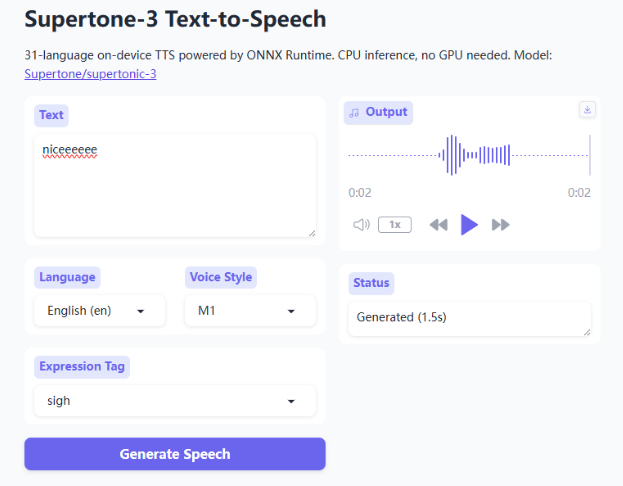

In [1]:
from IPython.display import Image
Image('ST.png')

### 示例音频

英语示例：
> "A gentle breeze moved through the open window while everyone listened to the story."

日语示例：
> "ふふっ、退屈してたところなの。ちょうどいい遊び相手、見つけたかも♪"

韩语示例：
> "혼자 떠나기엔 길이 험하구나. 이 낡은 검을 가져가거라."

情感标签示例：
> "`<laugh>`That's hilarious! I can't believe you actually did that!"

---

## 六、常见问题

### Q: 首次启动为什么需要等待？
A: 首次启动时模型会从 HuggingFace 自动下载（约 305MB），需要 1-2 分钟。后续启动直接使用缓存，秒级启动。

### Q: 支持中文吗？
A: 当前版本不支持中文合成，但支持日文、韩文和 26 种欧洲语言。中文支持可能在后续版本中推出。


### Q: 如何切换音色？
A: WebUI 提供多种预设音色（M1/M2/M3 男声系列，F1/F2/F3 女声系列），从下拉菜单选择即可。

---

## 七、技术架构

```
用户输入文本 → Gradio WebUI (:7860)
    ↓
supertone Python SDK
    ↓
ONNX Runtime 
    ↓
输出 WAV 音频文件
```

- 推理引擎：ONNX Runtime（CPU）
- 模型参数：99M
- 模型体积：305MB
- Web 框架：Gradio 4.44.1
- Python 版本：3.10
- 基础镜像：PyTorch 2.1.1 / CUDA 12.1.1 / Ubuntu 22.04